<a href="https://colab.research.google.com/github/marcos-vmiranda/mvp-analise-dados/blob/main/mvp3_analise_dados_marcos_miranda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Marcos Vinícius de Miranda

**Matrícula:** 4052025001185

**Dataset:** [Default of Credit Card Clients](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset)

# Descrição do Problema

O dataset ***Default of Credit Card Clients*** contém informações sobre pagamentos em atraso, fatores demográficos, dados de crédito, histórico de pagamentos e extratos de faturas de clientes de cartão de crédito em Taiwan, de abril de 2005 a setembro de 2005. O objetivo principal é avaliar como a probabilidade de inadimplência varia de acordo com as categorias de diferentes variáveis ​​demográficas. Ele foi obtido a partir do repositório kaggle (www.kaggle.com).

## Hipóteses do Problema

A partir da análise e exploração dos dados é esperado que as seguintes hipóteses sejam respondidas:

1. Qual variável demográfica é preditora mais forte de inadimplência?
2. Para a previsão de inadimplencia é mais relevante o limite de crédito, as características demográficas ou o histórico de pagamentos?

Após a etapa de preparação dos dados, um modelo poderá ser treinado a partir dos dados do dataset, então espera-se que seja possível estimar se haverá inadimplência de um cliente no mês seguinte a partir das informações de entrada.

## Tipo de Problema

Este é um problema de **classificação supervisionada**, uma vez que o cliente será classificado como inadimplente ou não a partir dos dados de entrada.

## Seleção de Dados

O dataset 'Default of Credit Card Clients' é um conjunto de dados disponível no UCI e Kaggle. Não é necessária uma etapa de seleção de dados externa, pois o dataset já está curado e pronto para uso.

## Atributos do Dataset

O dataset 'Default of Credit Card Clients' contém 30000 amostras e 25 atributos. A variável target é a coluna '***default.payment.next.month***':

- ***ID***: Identificação de cada cliente
- ***LIMIT_BAL***: Valor do crédito concedido em dólares taiwaneses (inclui crédito individual e familiar/suplementar)
- ***SEX***: Sexo (1=masculino, 2=feminino)
- ***EDUCATION***: (1=pós-graduação, 2=universidade, 3=ensino médio, 4=outros, 5=desconhecido, 6=desconhecido)
- ***MARRIAGE***: Estado civil (1=casado(a), 2=solteiro(a), 3=outros)
- ***AGE***: Idade em anos
- ***PAY_0***: Situação do pagamento em setembro de 2005 (-1=pagamento em dia, 1=atraso de um mês, 2=atraso de dois meses, … 8=atraso de oito meses, 9=atraso de nove meses ou mais)
- ***PAY_2***: Situação do pagamento em agosto de 2005 (escala igual à acima)
- ***PAY_3***: Situação do pagamento em julho de 2005 (escala igual à acima)
- ***PAY_4***: Situação do pagamento em junho de 2005 (escala igual à acima)
- ***PAY_5***: Situação do pagamento em maio de 2005 (escala igual à acima)
- ***PAY_6***: Situação do pagamento em abril de 2005 (escala igual à acima)
- ***BILL_AMT1***: Valor da fatura em setembro de 2005 (dólar NT)
- ***BILL_AMT2***: Valor da fatura em agosto de 2005 (dólar NT)
- ***BILL_AMT3***: Valor da fatura em julho de 2005 (dólar NT)
- ***BILL_AMT4***: Valor da fatura em junho de 2005 (dólar NT)
- ***BILL_AMT5***: Valor da fatura em maio de 2005 (dólar NT)
- ***BILL_AMT6***: Valor da fatura em abril de 2005 (dólar NT)
- ***PAY_AMT1***: Valor do pagamento anterior em setembro de 2005 (Dólar NT)
- ***PAY_AMT2***: Valor do pagamento anterior em agosto de 2005 (Dólar NT)
- ***PAY_AMT3***: Valor do pagamento anterior em julho de 2005 (Dólar NT)
- ***PAY_AMT4***: Valor do pagamento anterior em junho de 2005 (Dólar NT)
- ***PAY_AMT5***: Valor do pagamento anterior em maio de 2005 (Dólar NT)
- ***PAY_AMT6***: Valor do pagamento anterior em abril de 2005 (Dólar NT)
- ***default.payment.next.month***: Pagamento atrasado no próximo mês (inadimplente) (1=sim, 0=não)

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils import resample

In [4]:
url = "https://raw.githubusercontent.com/marcos-vmiranda/mvp-analise-dados/main/UCI_Credit_Card.csv"
# Lê o arquivo e carrega num dataframe pandas
df = pd.read_csv(url, delimiter=',')

In [5]:
# Exibe as primeiras linhas
df.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


In [6]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 30000

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset '***default.payment.next.month***' possui 30000 instâncias e 25 colunas. Algumas colunas possuem tipo numérico em ponto flutuante e outros são inteiros. Algumas variáveis são categóricas (SEX,MARRIAGE,EDUCATION, PAY_0 a PAY6), onde foi atribuído um valor inteiro representando cada categoria. A variável target (default.payment.next.month) também é inteira e categórica.

## Verificação de valores ausentes e duplicados

In [7]:
faltantes = df.isnull().sum()
print("Quantidade de valores faltantes:", faltantes[faltantes > 0].count())

duplicados = df.duplicated().sum()
print("Quantidade de linhas duplicadas:", duplicados)

if duplicated := df.duplicated().sum():
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicados removidos.")
else:
    print("Nenhum duplicado removido.")

Quantidade de valores faltantes: 0
Quantidade de linhas duplicadas: 0
Nenhum duplicado removido.


Como verificado acima, o dataset não possui valores ausentes ou duplicados. Devido a isso nenhum tratamento foi necessário.

## Distribuição da variável target

In [8]:
# Agrupa features pelo campo target
print("\nDistribuição da classe target:\n")
print(df.groupby('default.payment.next.month').size())


Distribuição da classe target:

default.payment.next.month
0    23364
1     6636
dtype: int64


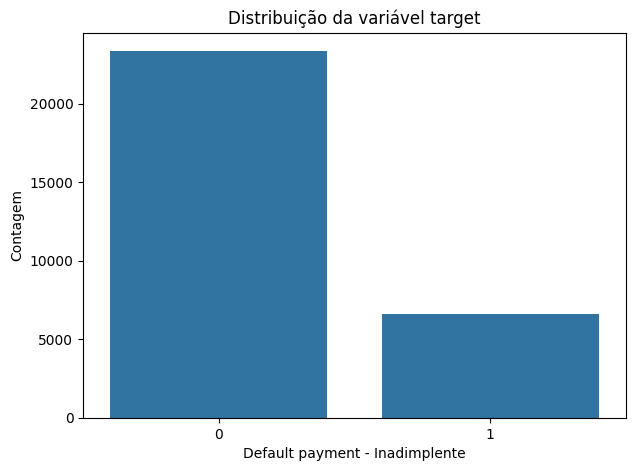

In [9]:
plt.figure(figsize=(7, 5))
# gráfico de barras simples
sns.countplot(x='default.payment.next.month', data=df)
plt.title('Distribuição da variável target')
plt.xlabel('Default payment - Inadimplente')
plt.ylabel('Contagem')
plt.show()

O gráfico de barras acima mostra que o dataset está desbalanceado, uma vez que existem muito mais amostras de clientes adimplentes do que inadimplentes. Devido a isso, o dataset precisa ser balanceado antes de ser utilizado para treinar um modelo.

## Distribuição de variáveis categóricas
Nessa etapa são avaliados se os valores das variáveis categóricas estão dentro dos valores esperados:
- SEX: Sexo (1=masculino, 2=feminino)
- EDUCATION: (1=pós-graduação, 2=universidade, 3=ensino médio, 4=outros, 5=desconhecido, 6=desconhecido)
- MARRIAGE: Estado civil (1=casado(a), 2=solteiro(a), 3=outros)
- AGE: Idade em anos
- PAY_X: Situação do pagamento em setembro de 2005 (-1=pagamento em dia, 1=atraso de um mês, 2=atraso de dois meses, … 8=atraso de oito meses, 9=atraso de nove meses ou mais)

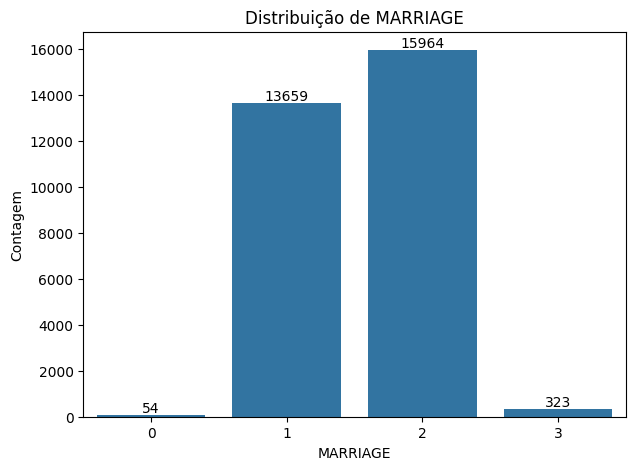

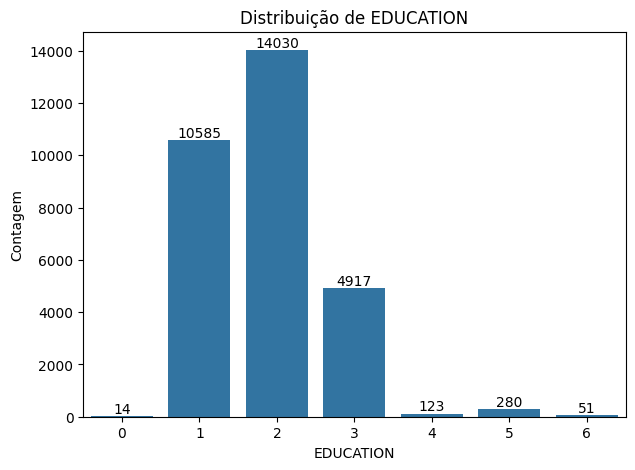

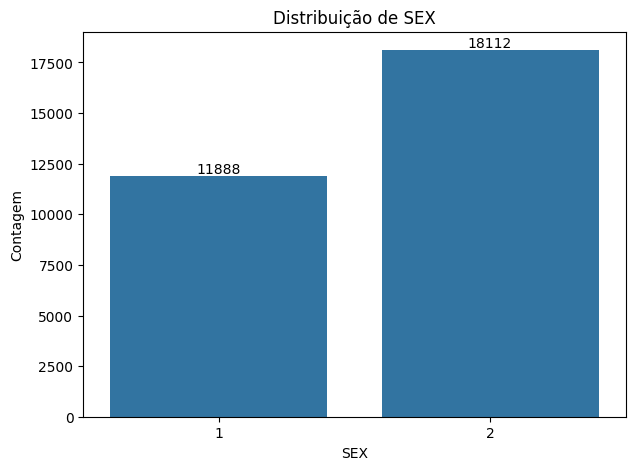

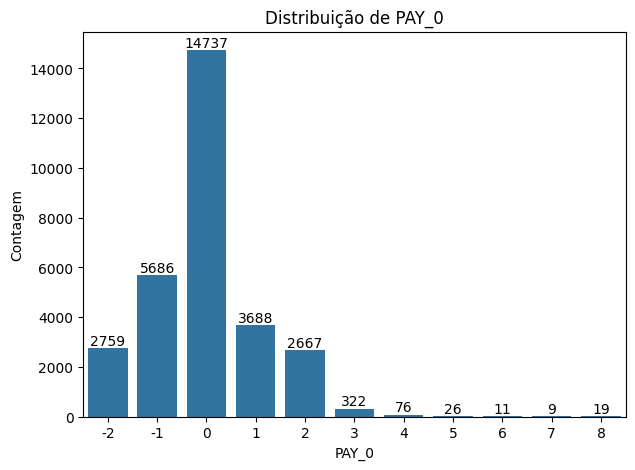

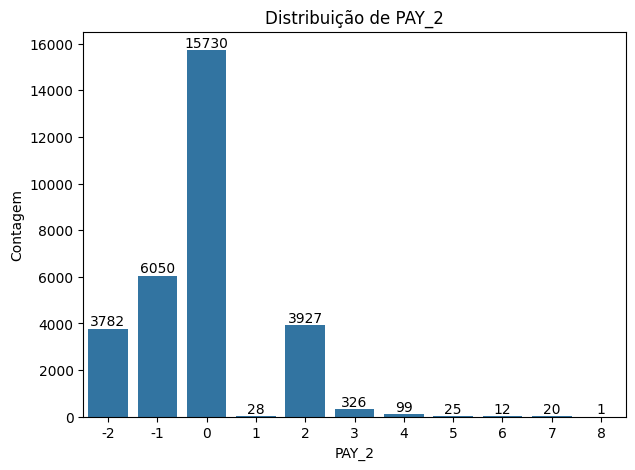

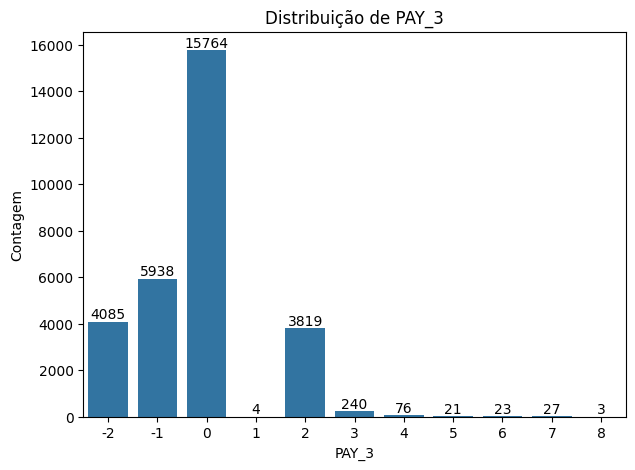

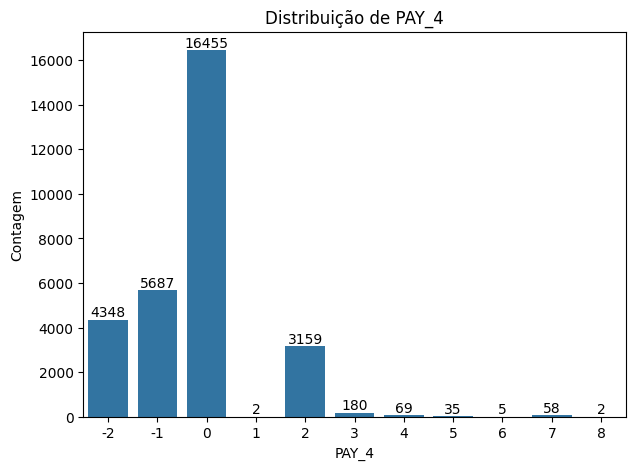

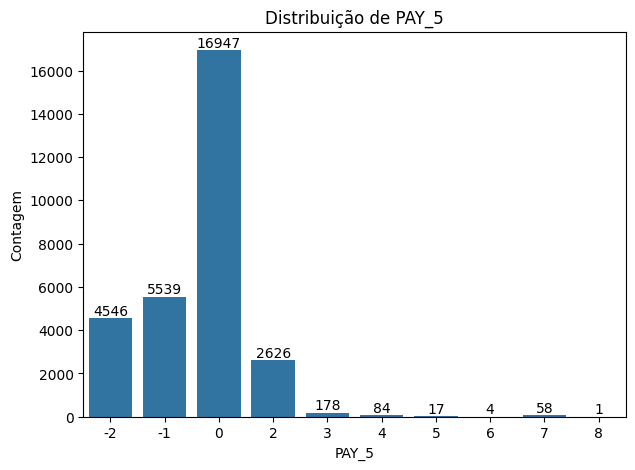

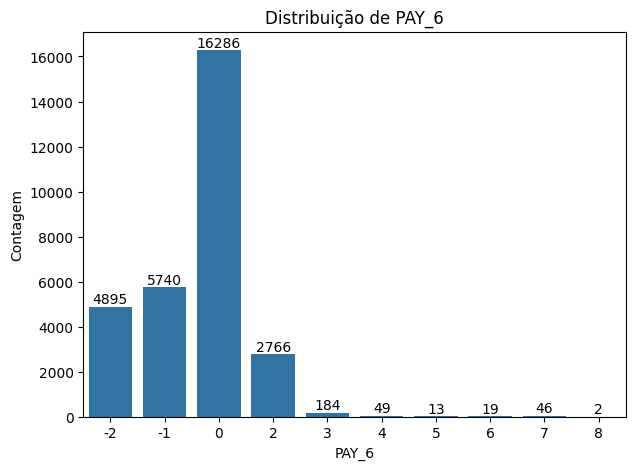

In [10]:
for col in ['MARRIAGE', 'EDUCATION', 'SEX','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
  plt.figure(figsize=(7, 5))
  # Plota um gráfico de barras simples
  ax=sns.countplot(x=col, data=df)
  plt.title(f"Distribuição de {col}")
  plt.xlabel(col)
  plt.ylabel('Contagem')
  # Adiciona os valores nas barras
  for container in ax.containers:
    ax.bar_label(container)
  plt.show()

A partir dos dados exibidos na distribuição das variáveis categóricas acima é possível perceber que a variável MARRIAGE possui alguns registros com valor 0, o que não é um valor válido. Para resolver esse problema, esses registros serão ajustados para 3 (outros) durante a limpeza do dataset.

O mesmo problema ocorre com a variável EDUCATION, que possui  valores inválidos (0). Também existem vários registros 5 (desconhecido) e 6 (desconhecido). Para resolver esse problema, esses registros serão ajustados para 4 (outros).

Quanto às variáveis PAY_0 a PAY6, são verificadas várias ocorrências de valores inválidos 0 e -2. Esses valores serão ajustados para -1 (em dia), já que foi verificado que o target está desbalanceado para os adimplentes.

A variável SEX não possui valores inválidos.

## Estatísticas Descritivas

As estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [11]:
# estatísticas descritivas básicas do dataset
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


A análise dos dados numéricos acima mostra que a variáveis BILL_AMT1 (valor da fatura 1) a BILL_AMT6 possuem valores mínimos negativos, o que não faz sentido. Essas linhas serão eliminadas do dataset durante a etapa de limpeza do dataset.

## Limpeza do dataset

Nessa etapa é feito o tratamento dos valores inconsistentes das variáveis categóricas, conforme visto na seção anterior.

In [12]:
# Reclassifica categorias inconsistentes como "4 = others"
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# Reclassifica valor 0 como categoria "3 = others"
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

# Reclassifica valor 0 e -2 como categoria "3 = others"
for col in ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']:
  df[col] = df[col].replace({-2: -1})
  df[col] = df[col].replace({0: -1})

# Elimina todas as linhas com faturas negativas
for col in ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']:
  df = df[df[col] >= 0]

Após a limpeza do dataset os dados são descritos novamente abaixo para confirmar que os valores negativos foram eliminados. O número de amostras foi reduzido de 30000 para 28070.

In [13]:
# estatísticas descritivas básicas do dataset
df.describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
ID,28070.0,14998.389633,8645.755255,1.0,7522.50,15022.5,22441.50,30000.0
LIMIT_BAL,28070.0,164443.522622,128985.392370,10000.0,50000.00,140000.0,230000.00,1000000.0
SEX,28070.0,1.606306,0.488577,1.0,1.00,2.0,2.00,2.0
EDUCATION,28070.0,1.851478,0.741905,1.0,1.00,2.0,2.00,4.0
MARRIAGE,28070.0,1.557499,0.521329,1.0,1.00,2.0,2.00,3.0
AGE,28070.0,35.450374,9.242283,21.0,28.00,34.0,41.00,79.0
PAY_0,28070.0,-0.416993,1.153941,-1.0,-1.00,-1.0,-1.00,8.0
PAY_2,28070.0,-0.510688,1.169096,-1.0,-1.00,-1.0,-1.00,8.0
PAY_3,28070.0,-0.539900,1.144497,-1.0,-1.00,-1.0,-1.00,8.0
PAY_4,28070.0,-0.607161,1.089875,-1.0,-1.00,-1.0,-1.00,8.0


## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.


Histograma do dataset:



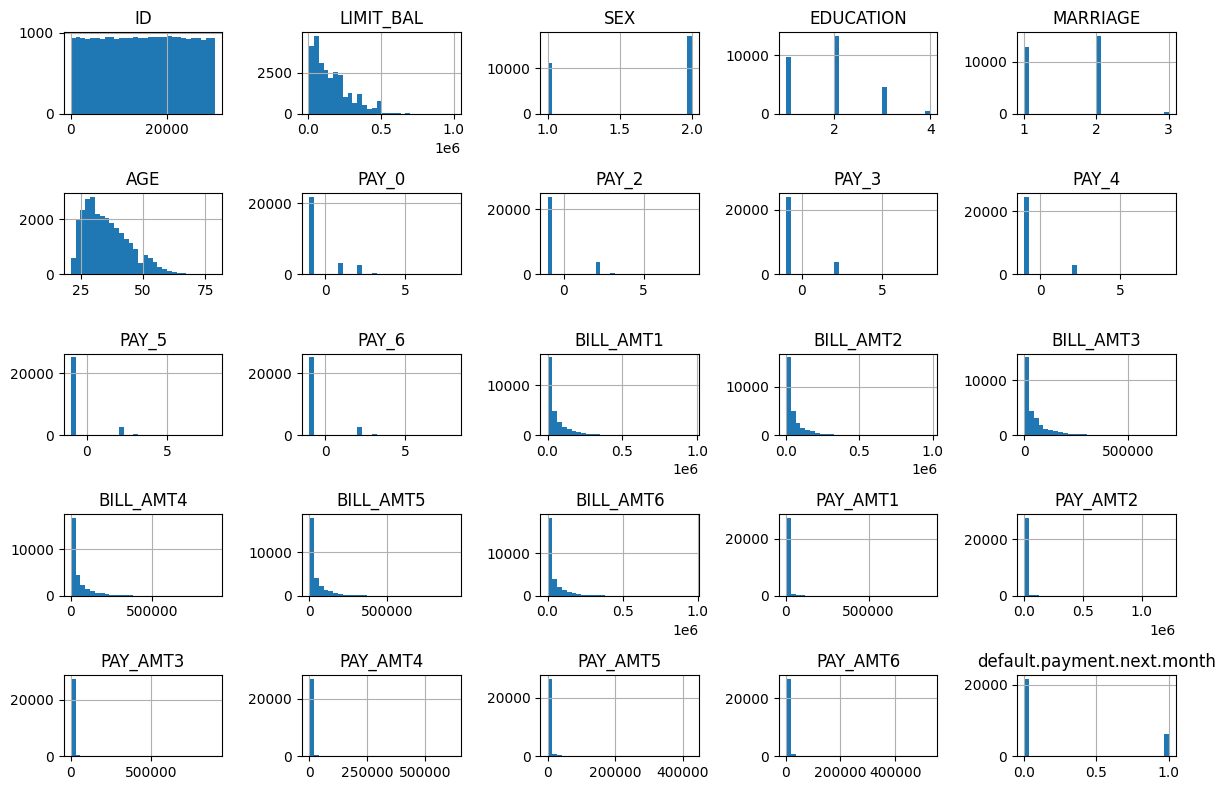

In [14]:
# Exibe os histogramas de todas as variáveis numéricas
print("\nHistograma do dataset:\n")
df.hist(bins=30, figsize=(12,8),  sharex=False, sharey=False)
plt.tight_layout()
plt.show()

Destacam-se 2 análises:

O histograma da variável LIMIT_BAL mostra como o limite de crédito é altamente variável.

O histograma da variável AGE mostra que os clientes estão mais concentrados na faixa de 25 a 40 anos.

## Análise de variáveis

A relação de proporção entre as variáveis categóricas e a variável target será analisada usando a função crosstab.

## Sexo

In [15]:
pd.crosstab(df['SEX'], df['default.payment.next.month'], normalize='index')

default.payment.next.month,0,1
SEX,,
1,0.752602,0.247398
2,0.789412,0.210588


Essa análise mostra a proporção de clientes inadimplentes por sexo. É possível verificar que existe uma distribuição semelhante entre Masculino (1) e Feminino (2), sendo um pouco maior no caso do masculino.

## Estado civil

In [16]:
pd.crosstab(df['MARRIAGE'], df['default.payment.next.month'], normalize='index')

default.payment.next.month,0,1
MARRIAGE,,
1,0.761607,0.238393
2,0.786685,0.213315
3,0.758523,0.241477


Verifica-se que existe um equilíbrio entre os inadimplentes em relação ao estado civil casado (1), solteiro (2) e outros(2), sendo um pouco menos frequente para os solteiros.

### Escolaridade

In [17]:
pd.crosstab(df['EDUCATION'], df['default.payment.next.month'], normalize='index')

default.payment.next.month,0,1
EDUCATION,,
1,0.805163,0.194837
2,0.759077,0.240923
3,0.743330,0.256670
4,0.923963,0.076037


Essa análise mostra que o maior nível de inadimplência está no ensino médio (3)

## Boxplot

O boxplot foi utilizado para entender o comportamento das variáveis LIMIT_BAL (limite de crédito) e AGE (Idade) para os casos com e sem previsão de inadimpência.


### Limite de crédito

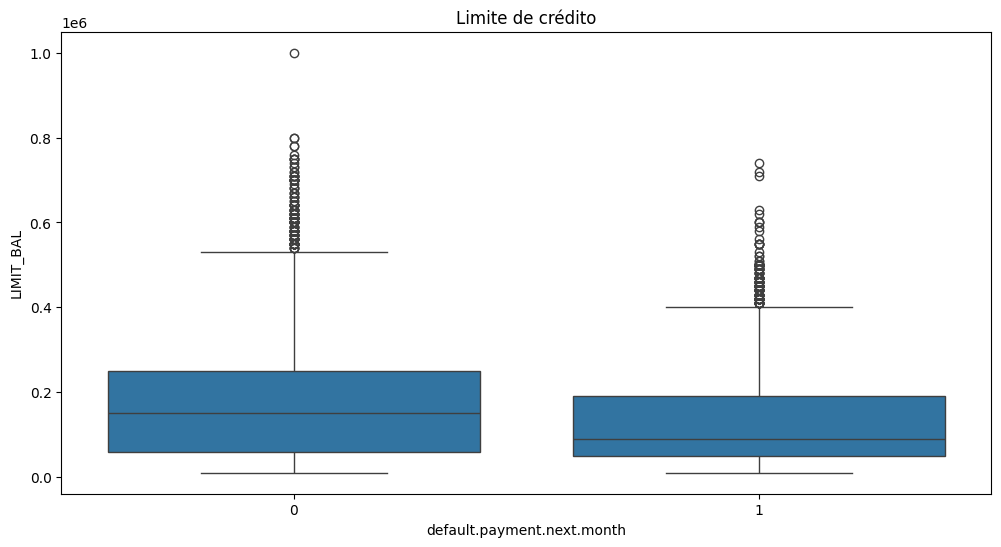

In [18]:
# boxplot com Seaborn
plt.figure(figsize=(12,6))
sns.boxplot(x='default.payment.next.month', y='LIMIT_BAL', data=df)
plt.title('Limite de crédito')
plt.show()

É possível perceber que existem muitos outliers no limite de crédito, ou seja, muitos clientes com limite alto. Porém isso ocorre tanto com clientes inadimplentes (1) como para os adimplentes (0), não sendo possível traçar uma correlação entre a inadimplencia e o limite. No caso dos inadimplentes, vê-se uma mediana menor, concluindo-se que a maioria nesse caso possui um limite menor.

### Idade

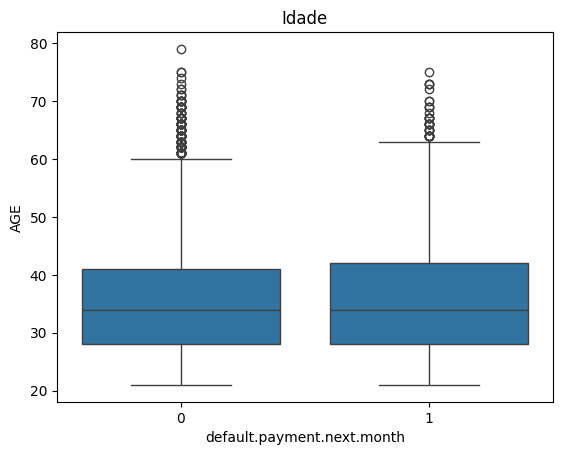

In [19]:
sns.boxplot(x='default.payment.next.month', y='AGE', data=df)
plt.title('Idade')
plt.show()

O bloxplot da variável AGE confirma que a maioria das amostra concentra-se entre 25 e 40 anos, como tinha sido visto anteriormente no histograma. Ainda assim existem alguns outliers entre 60 e 80 anos nos 2 casos da variável target.

### Faturas

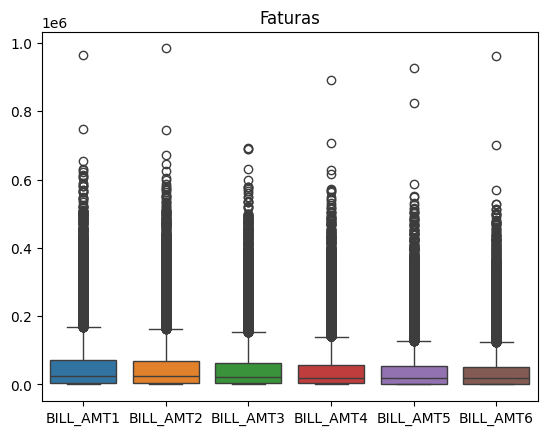

In [20]:
sns.boxplot(data = df.loc[:, ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']]) #BILL_AMT0 não existe
plt.title('Faturas')
plt.show()

A análise dos boxplots das faturas mostra uma distribuição não uniforme, com uma mediana próxima dos valores menores, mas muitos outliers com faturas de alto valor.

### Pagamentos

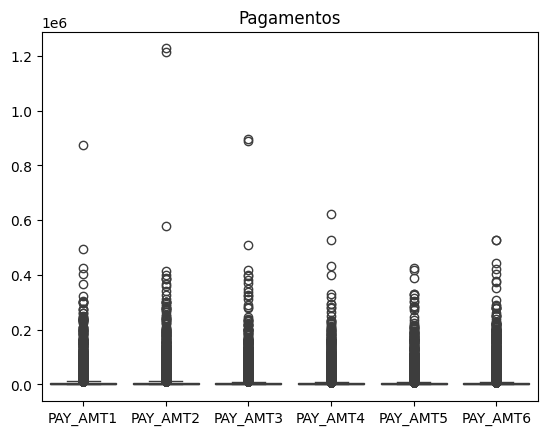

In [21]:
sns.boxplot(data = df.loc[:, ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']]) #PAY_AMT0 não existe
plt.title('Pagamentos')
plt.show()

A análise dos boxplots dos pagamentos é semelhante à das faturas, já que também mostra uma distribuição não uniforme, com uma mediana próxima dos valores menores, mas muitos outliers com faturas de alto valor.

## Matriz de Correlação

A matriz de correlação é uma tabela que mostra o grau de relação (correlação) entre todas as variáveis numéricas de um dataset, comparando cada variável com todas as outras. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.
A matriz abaixo foi exibida no formato de um mapa de calor para facilitar a visualização.

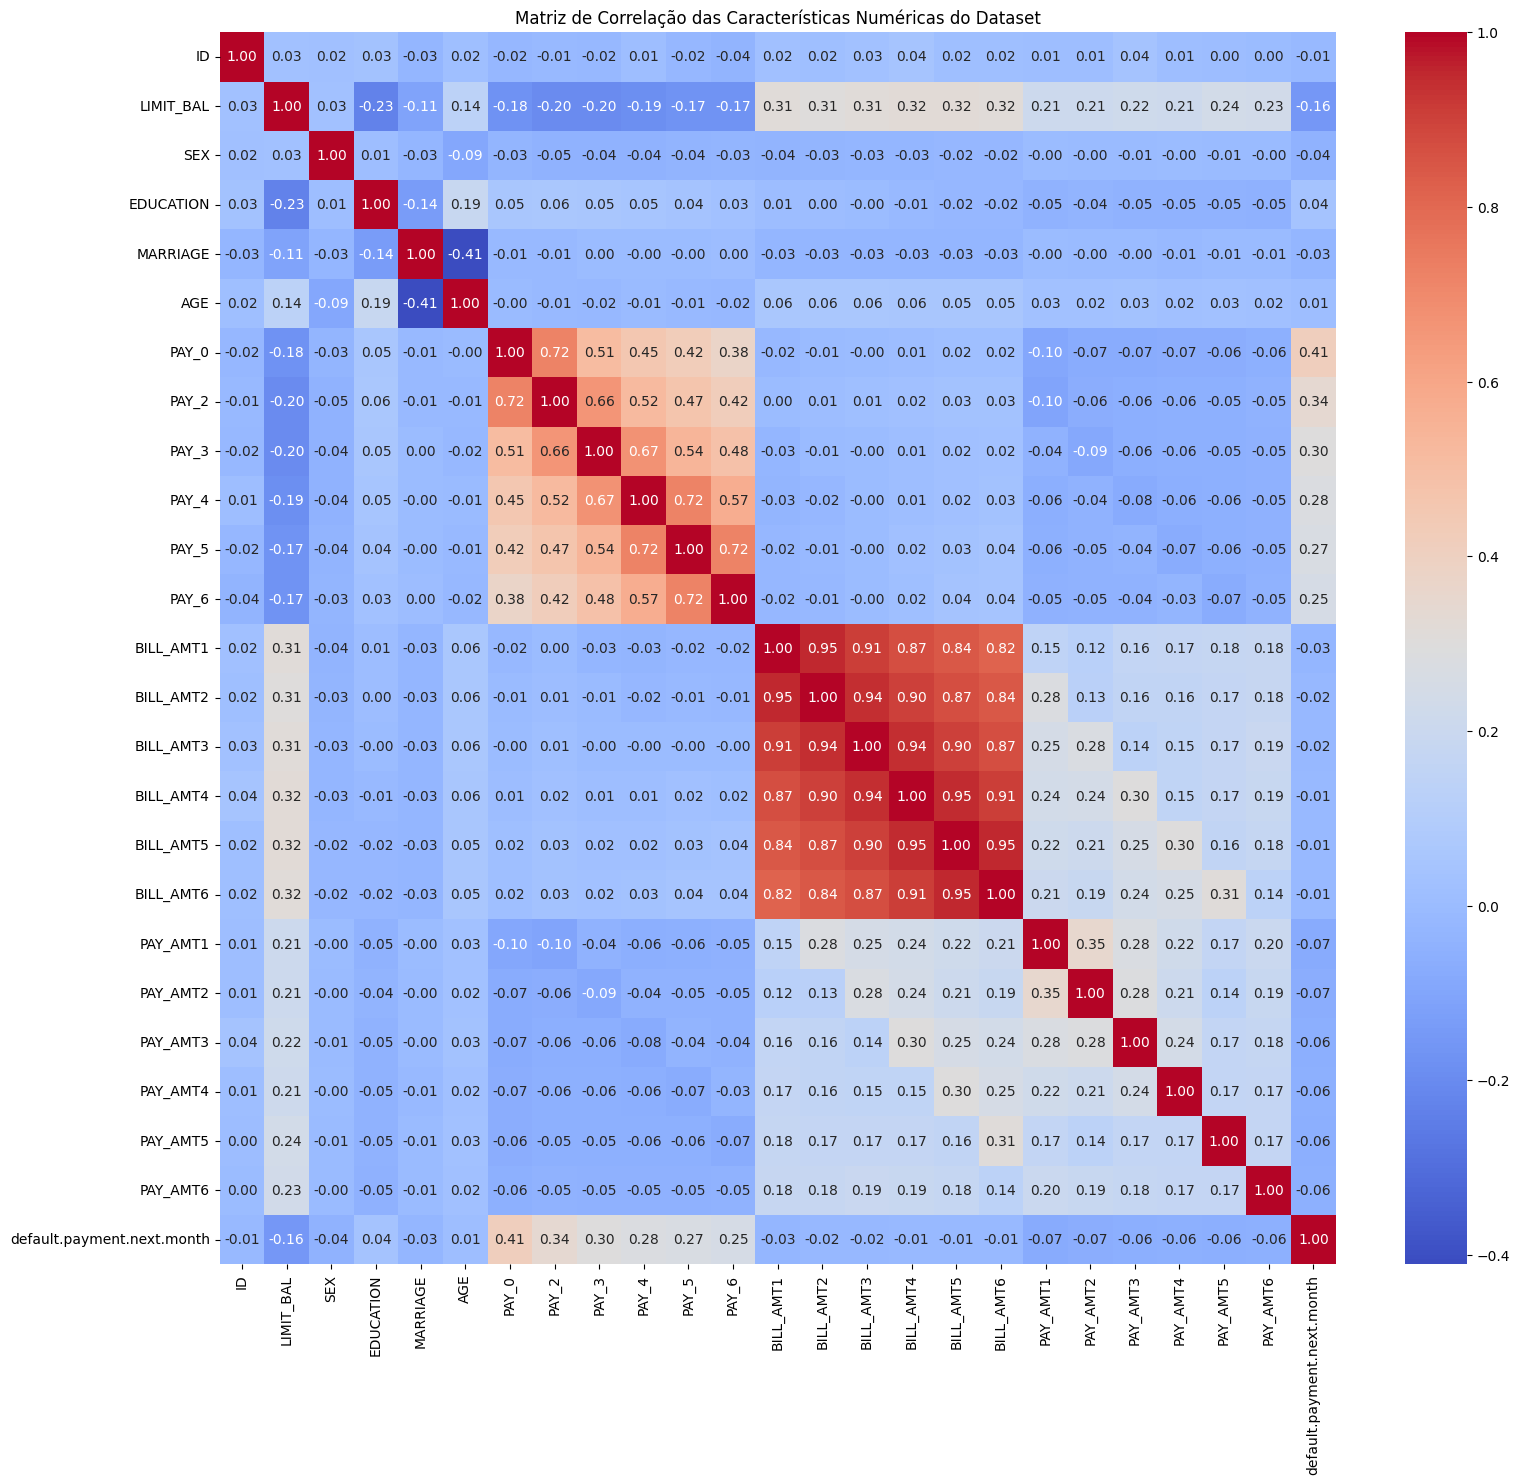

In [22]:
plt.figure(figsize=(18, 16))
# mapa de calor das variáveis numéricas
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset')
plt.show()

O mapa de calor da matriz de correlação revela que a variável target(default.payment.next.month) tem maior corelação com o limite de crédito (LIMIT_BAL) e a situação do pagamento (PAY_X), portanto essas são as variáveis que irão influenciar mais o modelo e devem ser mantidas.

A correlação da situação do pagamento é positiva, ou seja, quando maior o status da situação, maior a tendencia ao default (calote).

A correlação do limite de crédito é negativa, ou seja, quando menor o limite, maior a tendencia ao calote. Essa análise corrobora o que foi visto na análise do boxplot.

As demais variáveis possuem uma baixa correlação (menor que 0.1)  com o target, especialmente a variável AGE, que é a que possui a menor correlação. É recomendado considerar a remoção de algumas dessas variáveis (SEX, EDUCATION, MARRIAGE, AGE) para melhorar a performance do modelo.

Com relação às variáveis das faturas (BILL_AMT1 a BILL_AMT6), além de possuírem baixa correlação com o target, também possuem uma alta correlação entre si, o que também pode causar problemas ao modelo, uma vez que carregam informação redundante. Uma possível solução seria manter apenas uma delas e eliminar as outras ou criar uma nova variável com a média (feature engineering)

Uma análise semelhante pode ser feita com as variáveis das situações de pagamento (PAY_0 a PAY_1). Apesar de possuírem correlação razoável com o target, possuem uma alta correlação entre si. Nesse caso, uma solução seria manter apenas a PAY_0, que possui a maior correlação, ou eliminar todas e criar uma nova coluna com a soma dos meses em atraso (feature engineering). Isso poderá reduzir a multicolinearidade, melhorando a robustez e interpretabilidade do modelo.

As variáveis de pagamento (PAY_AMT1 a PAY_AMT6), possuem baixa correlação com o target e poderiam ser eliminadas ou substituídas por uma média.

# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

## Feature engineering
Nessa etapa serão criadas algumas novas variáveis que podem resumir e até substituir outras variáveis correlacionadas, tornando os dados mais informativos para o modelo. Para isso será utilizado o resultado da análise da Matriz de Correlação vista anteriormente.

- As colunas das faturas BILL_AMT1 ... BILL_AMT6 são altamente correlacionadas, portanto serão substituídas por uma média.

- As colunas dos pagamentos PAY_AMT1 ... PAY_AMT6 têm baixa correlação com o target, portanto serão substituídas por uma média.

- As colunas da situação dos pagamentos PAY_0 ... PAY6 são altamente correlacionadas, portanto serão substituídas por uma soma (quantidade de meses com atraso)

In [24]:
# Cria a coluna com a média das faturas
df['AVG_BILL'] = df[['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']].mean(axis=1)
# Cria a coluna com a média dos pagamentos
df['AVG_PAY'] = df[['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']].mean(axis=1)
# Cria a coluna com a quantidade de meses em atraso
df['NUM_DELAYS'] = (df[['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']] > 0).sum(axis=1)


## Seleção de características
Nessa etapa serão escolhidas quais variáveis devem ser utilizadas para treinar o modelo. Para isso será utilizado o resultado da análise da Matriz de Correlação vista anteriormente, com o objetivo de reduzir o número de variáveis mantendo (ou melhorando) a qualidade do modelo. Essa etapa é importante para:
- Evitar overfitting
- Melhorar a performance
- Reduzir o tempo de processamento
- Aumentar a interpretabilidade
- Remover ruído e redundância

Com base na análise da matriz será feito o seguinte:
- Remover a coluna ID, já que é somente um código sem valor semântico
- Remover a coluna AGE, que possui baixa correlação
- Manter a columa AVG_BILL e remover as colunas BILL_AMT2 a BILL_AMT6, que possuem alta correlação entre si.
- Manter a coluna SUM_PAY e remover as colunas PAY_0 a PAY6, que possuem alta correlação entre si
- Manter a coluna AVG_PAY e remover as colunas PAY_AMT1 a PAY_AMT6, que possuem baixa correlação com o target.

In [25]:
df =df.drop(['ID'],axis=1)
df =df.drop(['AGE'],axis=1)
df =df.drop(['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6'],axis=1)
df =df.drop(['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6'],axis=1)
df =df.drop(['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'],axis=1)

Após a seleção de características, o dataset ficou com as seguintes variáveis:

In [26]:
df.columns.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'default.payment.next.month',
 'AVG_BILL',
 'AVG_PAY',
 'NUM_DELAYS']

In [27]:
# Move a coluna target para o final do dataframe
cols = ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE','AVG_BILL', 'AVG_PAY', 'NUM_DELAYS','default.payment.next.month']
df = df[cols]

A nova matriz de correlação ficou da seguinte forma

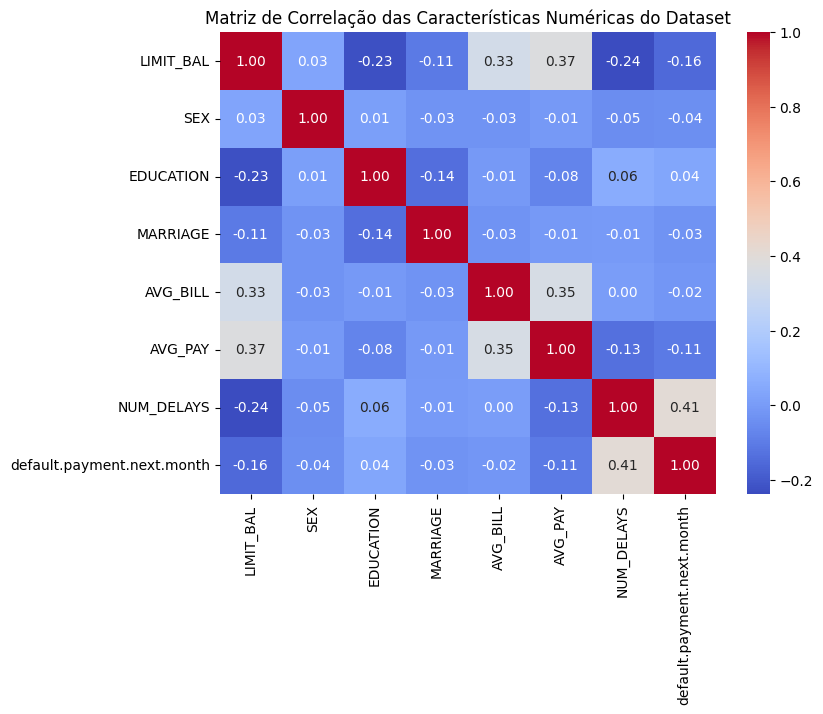

In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do Dataset')
plt.show()

A matriz de correlação mostra que a nova variável NUM_DELAYS possui uma boa correlação com o target

## Balanceamento

A etapa de análise exploratória mostrou que o dataset está desbalanceado no campo target, uma vez que existem muito mais cliente adimplentes. Devido a isso, será preciso aplicar uma técnica de balanceamento antes de treinar o modelo. A técnica escolhida foi o Undersampling, que remove exemplos da classe maior, uma vez que o dataset tinha uma quantidade considerável de registros. Outras técnicas poderiam ter sido aplicadas, como o Oversamping e o SMOTE.

In [29]:
df_maior = df[df['default.payment.next.month'] == 0]
df_menor = df[df['default.payment.next.month'] == 1]
df_maior_reduzida = resample(df_maior,replace=False,n_samples=len(df_menor),random_state=42)

df_balanceado = pd.concat([df_maior_reduzida, df_menor])

df_balanceado['default.payment.next.month'].value_counts()

,count
default.payment.next.month,
0,6318
1,6318


Como se pode ver acima, foi possível eliminar o desbalanceamento.

## Separação dos conjuntos de treino e teste
Nessa etapa os conjuntos de treino e teste são separados usando a técnica de holdout, com 20% dos dados para teste.

In [30]:
# Separar features (X) e target (y)
X = df_balanceado.drop('default.payment.next.month', axis=1)
y = df_balanceado['default.payment.next.month']

In [31]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (10108, 7)
Dimensões de X_test: (2528, 7)
Dimensões de y_train: (10108,)
Dimensões de y_test: (2528,)


## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.

No cenário em análise, é recomendada a normalização devido à escala de algumas variáveis (limite de crédito, por exemplo) ser muito diferente das demais variáveis.

A normalização é aplicada separadamente nos conjuntos de treino e teste para evitar o vazamento de dados.



In [33]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [34]:
# Aprende min e max APENAS de X_train
scaler_norm.fit(X_train)
X_train_normalized = scaler_norm.transform(X_train)
# Usa a média e o desvio padrão aprendidos de X_train
X_test_normalized = scaler_norm.transform(X_test)

In [35]:
# Exibir as primeiras linhas dos dados normalizados (como DataFrame para melhor visualização)
df_normalized = pd.DataFrame(X_train_normalized, columns=X_train.columns)

In [36]:
print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AVG_BILL   AVG_PAY  NUM_DELAYS
0   0.040404  1.0   0.000000       0.5  0.032425  0.007581    0.000000
1   0.292929  1.0   0.000000       0.5  0.041166  0.013571    0.000000
2   0.000000  1.0   0.333333       0.5  0.004429  0.003746    0.666667
3   0.020202  0.0   0.333333       0.5  0.033441  0.032210    0.000000
4   0.040404  1.0   0.333333       0.5  0.035177  0.005883    0.000000


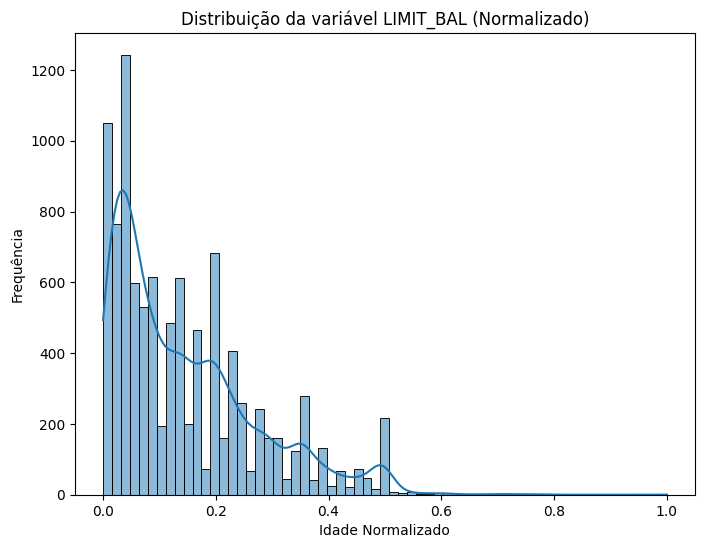

In [37]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['LIMIT_BAL'], kde=True)
plt.title('Distribuição da variável LIMIT_BAL (Normalizado)')
plt.xlabel('Idade Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *LIMIT_BAL* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

# Respondendo as hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou?

Qual variável demográfica é preditora mais forte de inadimplência?
Para a previsão de inadimplencia é mais relevante o limite de crédito, as características demográficas ou o histórico de pagamentos?


## Hipótese 1

Qual variável demográfica é preditora mais forte de inadimplência?

Resp. A matriz de correlação mostra que a variável SEX é a demográfica que possui a maior correlação com a variável target, apesar de não se ser uma alta correlação.

## Hipótese 2
Para a previsão de inadimplencia é mais relevante o limite de crédito, as características demográficas ou o histórico de pagamentos?

Resp. A matriz de correlação mostra que a variável mais relevante é o histórico de pagamentos (PAY_0 a PAY_6), seguida do limite de crédito (LIMIT_BAL). Nesse caso observou-se uma alta correlação.

# Conclusão

A análise e pré-processamento do dataset *Default of Credit Card Clients* demonstra a importância de entender a estrutura dos dados antes da modelagem.

O dataset apresenta desbalanceamento entre clientes inadimplentes e não inadimplentes, sendo necessário aplicar uma técnica de balanceamento. Foram necessárias etapas de limpeza e normalização, incluindo tratamento de categorias inconsistentes.
A análise exploratória permitiu identificar relações relevantes entre histórico de atraso, limite de crédito, pagamentos anteriores e a variável alvo.
O problema foi tratado como uma tarefa de classificação supervisionada.

Por fim, as duas hipóteses levantadas foram validadas.